##EXPERIMENTS ON SIMULATED DATA

In [3]:
%config InlineBackend.figure_format = 'retina'


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sldp_opt_utils  
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

In [4]:
# ===========================
# 1. Define oscillation functions
# ===========================

def calculate_oscillation_sq_norm(rect) -> float:
    """
    Calculates the oscillation of f(x,y) = x^2 + y^2 for a rectangle from sldp_utils.
    """
    # Access fields x_min, x_max of the Rectangle class
    max_f = max(rect.x_min**2, rect.x_max**2) + max(rect.y_min**2, rect.y_max**2)
    
    if rect.x_min <= 0 <= rect.x_max:
        min_x_sq = 0.0
    else:
        min_x_sq = min(rect.x_min**2, rect.x_max**2)
        
    if rect.y_min <= 0 <= rect.y_max:
        min_y_sq = 0.0
    else:
        min_y_sq = min(rect.y_min**2, rect.y_max**2)
        
    return max_f - (min_x_sq + min_y_sq)


def calculate_oscillation_rbf(rect, sigma: float = 2.0) -> float:
    """
    Calculates the oscillation of f(x,y) = exp(-(x^2+y^2)/2sigma^2)
    """
    # r_min
    if rect.x_min <= 0 <= rect.x_max: dx = 0.0 
    else: dx = min(rect.x_min**2, rect.x_max**2)
    
    if rect.y_min <= 0 <= rect.y_max: dy = 0.0 
    else: dy = min(rect.y_min**2, rect.y_max**2)
    r2_min = dx + dy
    
    # r_max
    r2_max = max(rect.x_min**2, rect.x_max**2) + max(rect.y_min**2, rect.y_max**2)
    
    return np.exp(-r2_min / (2*sigma**2)) - np.exp(-r2_max / (2*sigma**2))



In [5]:

# QuadTree parameters
BOUNDS = (-10.0, -10.0, 10.0, 10.0) 
Q_PARAM = 100; C_PARAM = 6.0; MAX_DEPTH = 40; DELTA = 0.05

# Simulation parameters
N_list = [2000, 16000, 32000, 64000] # Add as needed: [2000, 16000, 32000]
eps_range = [0.5, 1.0, 2.0, 4.0, 8.0, 12.0]
n_sims = 60 # Number of repetitions
q_split = 0.5 

# === CHANGE: Data structures for storing RAW values ===
# results[N][eps][method] -> list of n_sims predicted means
results = {N: {e: {'dp': [], 'ldp': [], 'sldp': []} for e in eps_range} for N in N_list}

# true_means[N] -> list of n_sims true means (one for each data generation)
true_means = {N: [] for N in N_list}

# Global oscillation
root_rect = sldp_opt_utils.Rectangle(*BOUNDS)
global_osc = calculate_oscillation_sq_norm(root_rect)

# ===========================
# 2. Run loop
# ===========================

for N in N_list:
    print(f"Running N={N}...")
    
    for sim_i in range(n_sims):
        rng = np.random.default_rng()
        print(f" Simulation {sim_i+1}/{n_sims}...")
        # Data generation
        pts = rng.normal(0, 1.5, size=(N, 2))
        pts = np.clip(pts, BOUNDS[0], BOUNDS[2]-1e-9)
        
        f_vals = pts[:, 0]**2 + pts[:, 1]**2
        mu_t = np.mean(f_vals)
        
        # Save the true mean for this simulation
        true_means[N].append(mu_t)
        
        for e in eps_range:
            # print(f"  Epsilon={e}...")
            # --- 1. DP Centralized ---
            # Save the PREDICTION ITSELF (mu_t + noise)
            dp_noise = rng.laplace(0, global_osc/e)
            results[N][e]['dp'].append(mu_t + dp_noise/N)
            
            # --- 2. LDP Standard ---
            ldp_noise = rng.laplace(0, global_osc/e, size=N)
            results[N][e]['ldp'].append(np.mean(f_vals + ldp_noise))
            
            # --- 3. SLDP (QuadTree) ---
            e_tree = e * q_split
            e_val = e * (1 - q_split)
            
            leaves = sldp_opt_utils.run_dp_quadtree_optimized(
                        dataset=pts, 
                        epsilon=e_tree, 
                        Q=Q_PARAM, 
                        C=C_PARAM, 
                        T=MAX_DEPTH, 
                        delta=DELTA, # Pass DELTA (which is 0.05)
                        bounds=BOUNDS, 
                        rng=rng
                    )
            
            weighted_sum = 0.0
            rem_idx = np.arange(N)
            
            for leaf in leaves:
                if len(rem_idx) == 0: break
                sub_pts = pts[rem_idx]
                mask = (sub_pts[:,0] >= leaf.x_min) & (sub_pts[:,0] < leaf.x_max) & \
                       (sub_pts[:,1] >= leaf.y_min) & (sub_pts[:,1] < leaf.y_max)
                cur_idx = rem_idx[mask]
                
                if len(cur_idx) > 0:
                    local_osc = calculate_oscillation_sq_norm(leaf)
                    vals = f_vals[cur_idx]
                    noise = rng.laplace(0, local_osc/e_val, size=len(cur_idx))
                    weighted_sum += np.sum(vals + noise)
                    rem_idx = rem_idx[~mask]
            
            results[N][e]['sldp'].append(weighted_sum / N)

Running N=2000...
 Simulation 1/60...
 Simulation 2/60...
 Simulation 3/60...
 Simulation 4/60...
 Simulation 5/60...
 Simulation 6/60...
 Simulation 7/60...
 Simulation 8/60...
 Simulation 9/60...
 Simulation 10/60...
 Simulation 11/60...
 Simulation 12/60...
 Simulation 13/60...
 Simulation 14/60...
 Simulation 15/60...
 Simulation 16/60...
 Simulation 17/60...
 Simulation 18/60...
 Simulation 19/60...
 Simulation 20/60...
 Simulation 21/60...
 Simulation 22/60...
 Simulation 23/60...
 Simulation 24/60...
 Simulation 25/60...
 Simulation 26/60...
 Simulation 27/60...
 Simulation 28/60...
 Simulation 29/60...
 Simulation 30/60...
 Simulation 31/60...
 Simulation 32/60...
 Simulation 33/60...
 Simulation 34/60...
 Simulation 35/60...
 Simulation 36/60...
 Simulation 37/60...
 Simulation 38/60...
 Simulation 39/60...
 Simulation 40/60...
 Simulation 41/60...
 Simulation 42/60...
 Simulation 43/60...
 Simulation 44/60...
 Simulation 45/60...
 Simulation 46/60...
 Simulation 47/60...
 Sim

## PLOT MSE (FIGURE 2 (a))

<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
/var/folders/qy/_74_pr7d2td740bq9dt07vz80000gn/T/ipykernel_97715/1399956823.py:24: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Privacy Budget ($\epsilon$)')


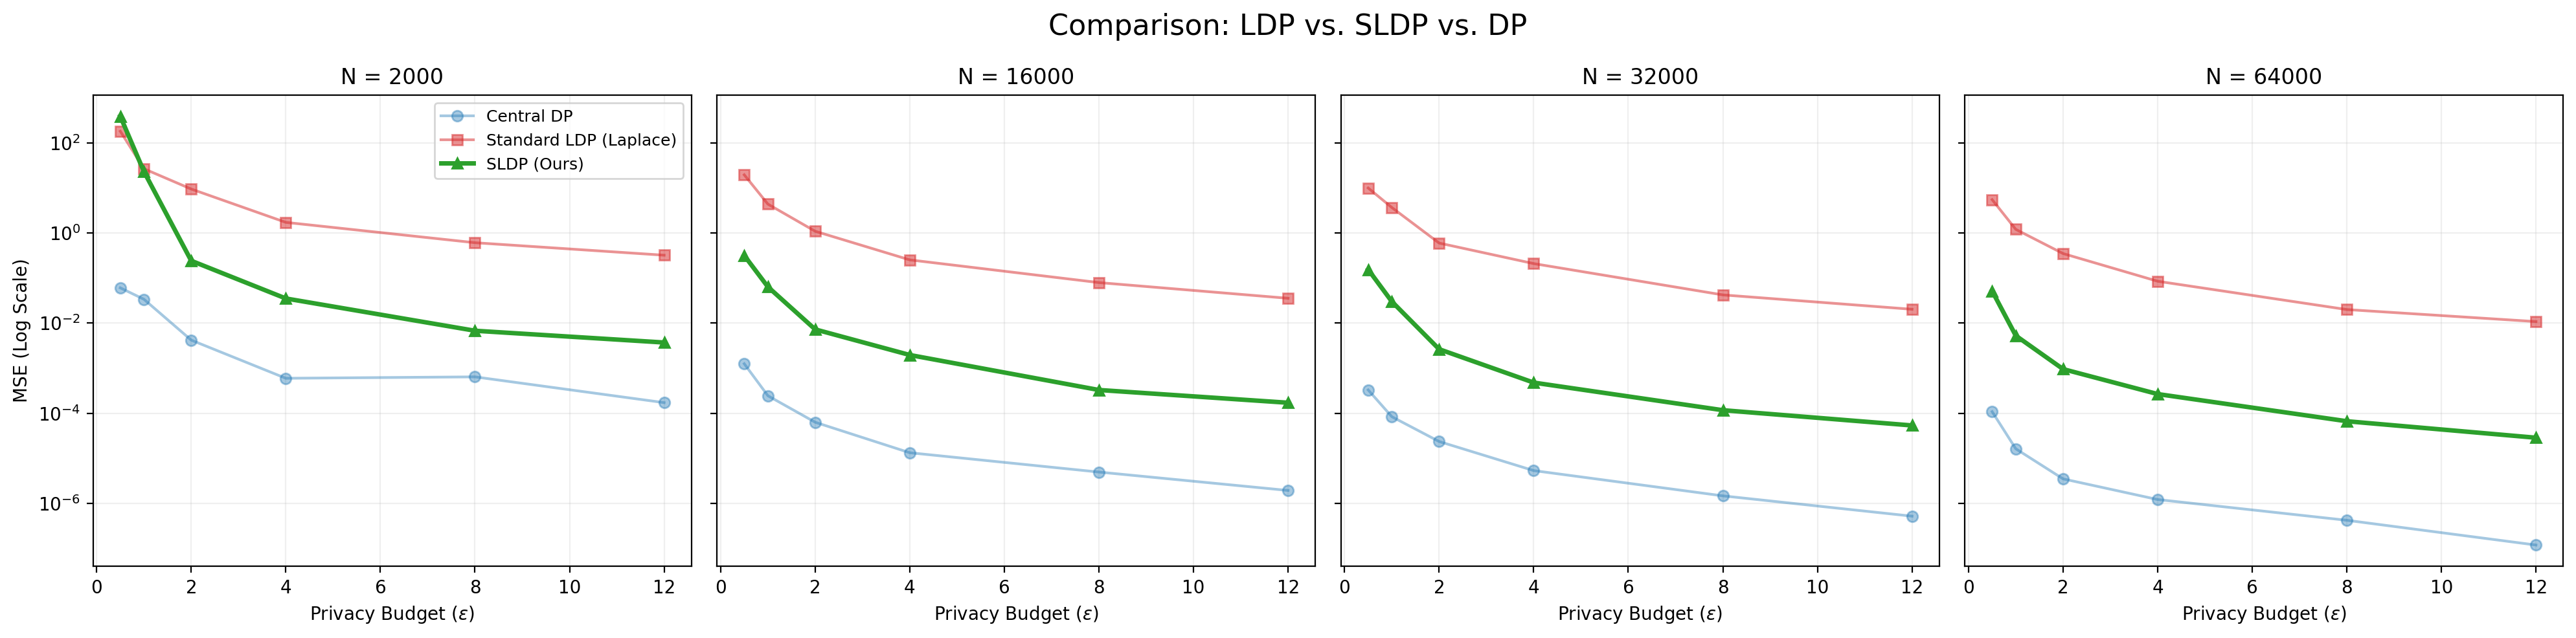

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
DOMAIN_DIAMETER = 20.0  # the domain is [-10, 10]

for idx, N in enumerate(N_list):
    ax = axes[idx]
    


    mse_dp = [np.mean((np.array(results[N][e]['dp']) - true_means[N])**2) for e in eps_range]
    mse_ldp = [np.mean((np.array(results[N][e]['ldp']) - true_means[N])**2) for e in eps_range]
    mse_sldp = [np.mean((np.array(results[N][e]['sldp']) - true_means[N])**2) for e in eps_range]


    ax.plot(eps_range, mse_dp, 'o-', label='Central DP', color='tab:blue', alpha=0.4)
    

    ax.plot(eps_range, mse_ldp, 's-', label='Standard LDP (Laplace)', color='tab:red', alpha=0.5)


    ax.plot(eps_range, mse_sldp, '^-', label='SLDP (Ours)', color='tab:green', linewidth=2.5)
    

    ax.set_title(f'N = {N}')
    ax.set_xlabel('Privacy Budget ($\epsilon$)')
    ax.set_yscale('log') 
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if idx == 0:
        ax.set_ylabel('MSE (Log Scale)')
        ax.legend(fontsize=9)

plt.suptitle('Comparison: LDP vs. SLDP vs. DP', fontsize=16)
plt.tight_layout()
plt.show()

## PLOT ERROR BARS (FIGURE 2 (b))

<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\e'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\e'
/var/folders/qy/_74_pr7d2td740bq9dt07vz80000gn/T/ipykernel_97715/2753945889.py:82: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Estimation Error ($x - \mu$)', fontsize=12)
/var/folders/qy/_74_pr7d2td740bq9dt07vz80000gn/T/ipykernel_97715/2753945889.py:92: SyntaxWarning: invalid escape sequence '\e'
  fig.supxlabel('Privacy Budget ($\epsilon$)', fontsize=13)


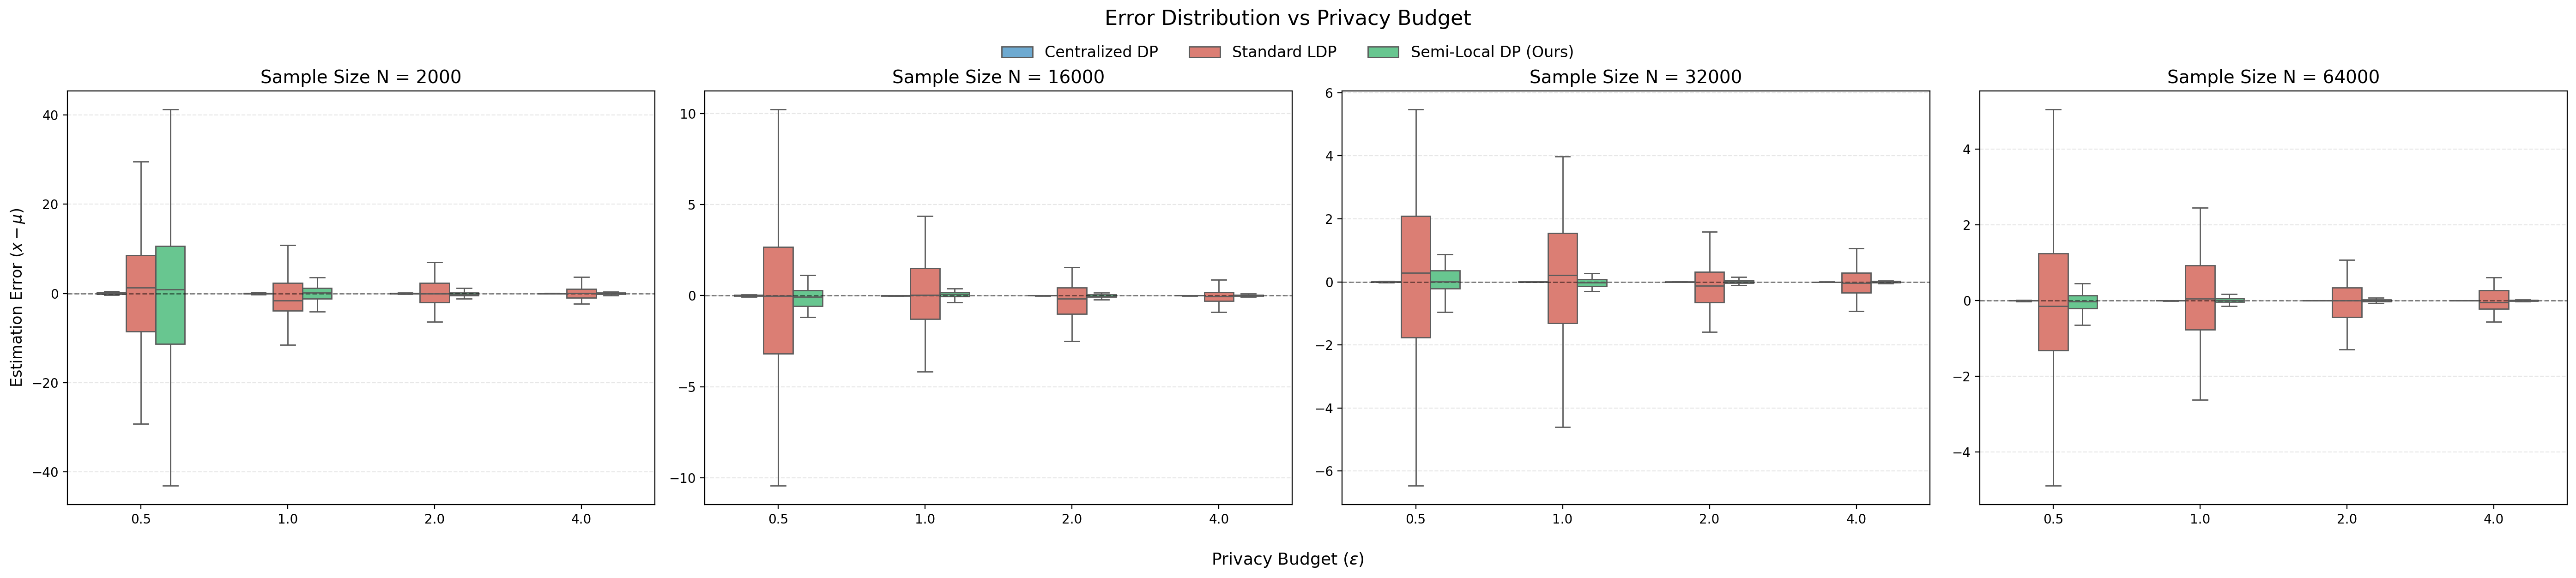

In [7]:

# ==========================================
# ERROR BARS
# ==========================================

records = []

for N in N_list:
    # true_means[N] is a list of true means for each of the n_sims simulations
    current_true_mean = np.array(true_means[N])
    data_dict = results[N] 
    
    for e in data_dict.keys():
        # Filter by epsilon 
        # If you have eps_range = [0.5, 1.0, 2.0, 4.0], then 4.0 will be cut off by the condition < 3.5
        if (e > 0.4) and (e < 5.5): 
            for method_name in ['dp', 'ldp', 'sldp']:
                estimates = data_dict[e][method_name]
                estimates_arr = np.array(estimates)
                
                # Calculate error for each simulation: (Prediction - Truth)
                # Thanks to numpy, this happens element-wise
                errors = estimates_arr - current_true_mean
                
                for err in errors:
                    records.append({
                        'N': N,
                        'Epsilon': e,
                        'Method': method_name,
                        'Error': err
                    })

df = pd.DataFrame(records)

# --- 2. Plot Setup ---
unique_Ns = df['N'].unique()
num_Ns = len(unique_Ns)

# squeeze=False ensures that axes is always an array, even if there is only one N
fig, axes = plt.subplots(1, num_Ns, figsize=(7 * num_Ns, 6), squeeze=False)
axes = axes.flatten()

# Color palette
palette = {
    'dp':   '#5DADE2', # Blue
    'ldp':  '#EC7063', # Red
    'sldp': '#58D68D'  # Green
}

# Nice names for the legend
names_map = {
    'dp': 'Centralized DP',
    'ldp': 'Standard LDP',
    'sldp': 'Semi-Local DP (Ours)'
}

for i, N in enumerate(unique_Ns):
    ax = axes[i]
    subset = df[df['N'] == N]
    
    # Draw Boxplot
    sns.boxplot(
        data=subset,
        x='Epsilon',
        y='Error',
        hue='Method',
        palette=palette,
        ax=ax,
        showfliers=False, # Hide outlier points to make the plot cleaner
        width=0.6         
    )
    
    # Zero line (ideal prediction)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # --- Styling ---
    ax.set_title(f'Sample Size N = {N}', fontsize=14)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_xlabel('') 
    
    # Y-axis label only on the left
    if i == 0:
        ax.set_ylabel('Estimation Error ($x - \mu$)', fontsize=12)
    else:
        ax.set_ylabel('')
        
    # Remove individual legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# --- 3. General Elements ---
fig.suptitle('Error Distribution vs Privacy Budget', fontsize=16, y=1.02)
fig.supxlabel('Privacy Budget ($\epsilon$)', fontsize=13)

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
new_labels = [names_map.get(l, l) for l in labels]

fig.legend(
    handles, 
    new_labels, 
    loc='upper center', 
    ncol=3, 
    frameon=False, 
    bbox_to_anchor=(0.5, 0.98),
    fontsize=12
)

plt.tight_layout()
plt.show()

## PLOT FUNCTION VALUE RELEASE (FIG. 1 -- HORIZONTAL)

In [8]:
# ==========================================
# 1. DATA GENERATION AND TREE CONSTRUCTION
# ==========================================
N_plot = 30000  
eps_plot = 1.0  
sigma_plot = 2.0
q_split_plot = 0.5

# QuadTree parameters
BOUNDS = (-10, -10, 10, 10)
Q_PARAM = 100
C_PARAM = 6.0
MAX_DEPTH = 15
DELTA = 0.05 # Simplified reliability parameter

print("1. Generating Data...")
rng = np.random.default_rng()
# Generate Gaussian at the center (as in your example)
pts = rng.normal(0, 2.0, size=(N_plot, 2))
pts = np.clip(pts, BOUNDS[0], BOUNDS[2]-1e-9)

# 1. TRUE VALUES
f_vals = np.exp(-(pts[:, 0]**2 + pts[:, 1]**2) / (2 * sigma_plot**2))

# Global oscillation for the root (for LDP)
root_rect = sldp_opt_utils.Rectangle(*BOUNDS)
global_osc_plot = calculate_oscillation_rbf(root_rect, sigma=sigma_plot)

print("2. Building QuadTree (New Module)...")
e_tree = eps_plot * q_split_plot
e_val = eps_plot * (1 - q_split_plot)

# --- CALLING NEW MODULE ---
leaves = sldp_opt_utils.run_dp_quadtree_optimized(
    dataset=pts,
    epsilon=e_tree,
    Q=Q_PARAM,
    C=C_PARAM,
    T=MAX_DEPTH,
    delta=DELTA,
    bounds=BOUNDS,
    rng=rng
)

print(f"   Tree built: {len(leaves)} leaves.")

print("3. Calculating Noisy Signals...")

# 2. STANDARD LDP
noise_ldp = rng.laplace(0, global_osc_plot/eps_plot, size=N_plot)
vals_ldp = f_vals + noise_ldp

# 3. SLDP (Ours) - Vectorized calculation over leaves
vals_sldp = np.zeros(N_plot)
# To avoid searching for points slowly again, we use simple assignment
# (Ideally, run_dp_quadtree could return indices, but we will use masks; it is fast for N=30k)

remaining_idxs = np.arange(N_plot)
pts_remaining = pts.copy() # Copy for filtering (or use indices)

for leaf in leaves:
    # Find points falling into the leaf
    mask = (pts[:, 0] >= leaf.x_min) & (pts[:, 0] < leaf.x_max) & \
           (pts[:, 1] >= leaf.y_min) & (pts[:, 1] < leaf.y_max)
    
    idxs = np.where(mask)[0]
    
    if len(idxs) > 0:
        local_osc = calculate_oscillation_rbf(leaf, sigma=sigma_plot)
        noise = rng.laplace(0, local_osc/e_val, size=len(idxs))
        vals_sldp[idxs] = f_vals[idxs] + noise

1. Generating Data...
2. Building QuadTree (New Module)...
   Tree built: 241 leaves.
3. Calculating Noisy Signals...


<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
/var/folders/qy/_74_pr7d2td740bq9dt07vz80000gn/T/ipykernel_97715/525041422.py:45: SyntaxWarning: invalid escape sequence '\e'
  (vals_sldp, f'Semi-Local DP (Ours, $\epsilon={eps_plot}$)'),
/var/folders/qy/_74_pr7d2td740bq9dt07vz80000gn/T/ipykernel_97715/525041422.py:46: SyntaxWarning: invalid escape sequence '\e'
  (vals_ldp,  f'Standard LDP ($\epsilon={eps_plot}$)')


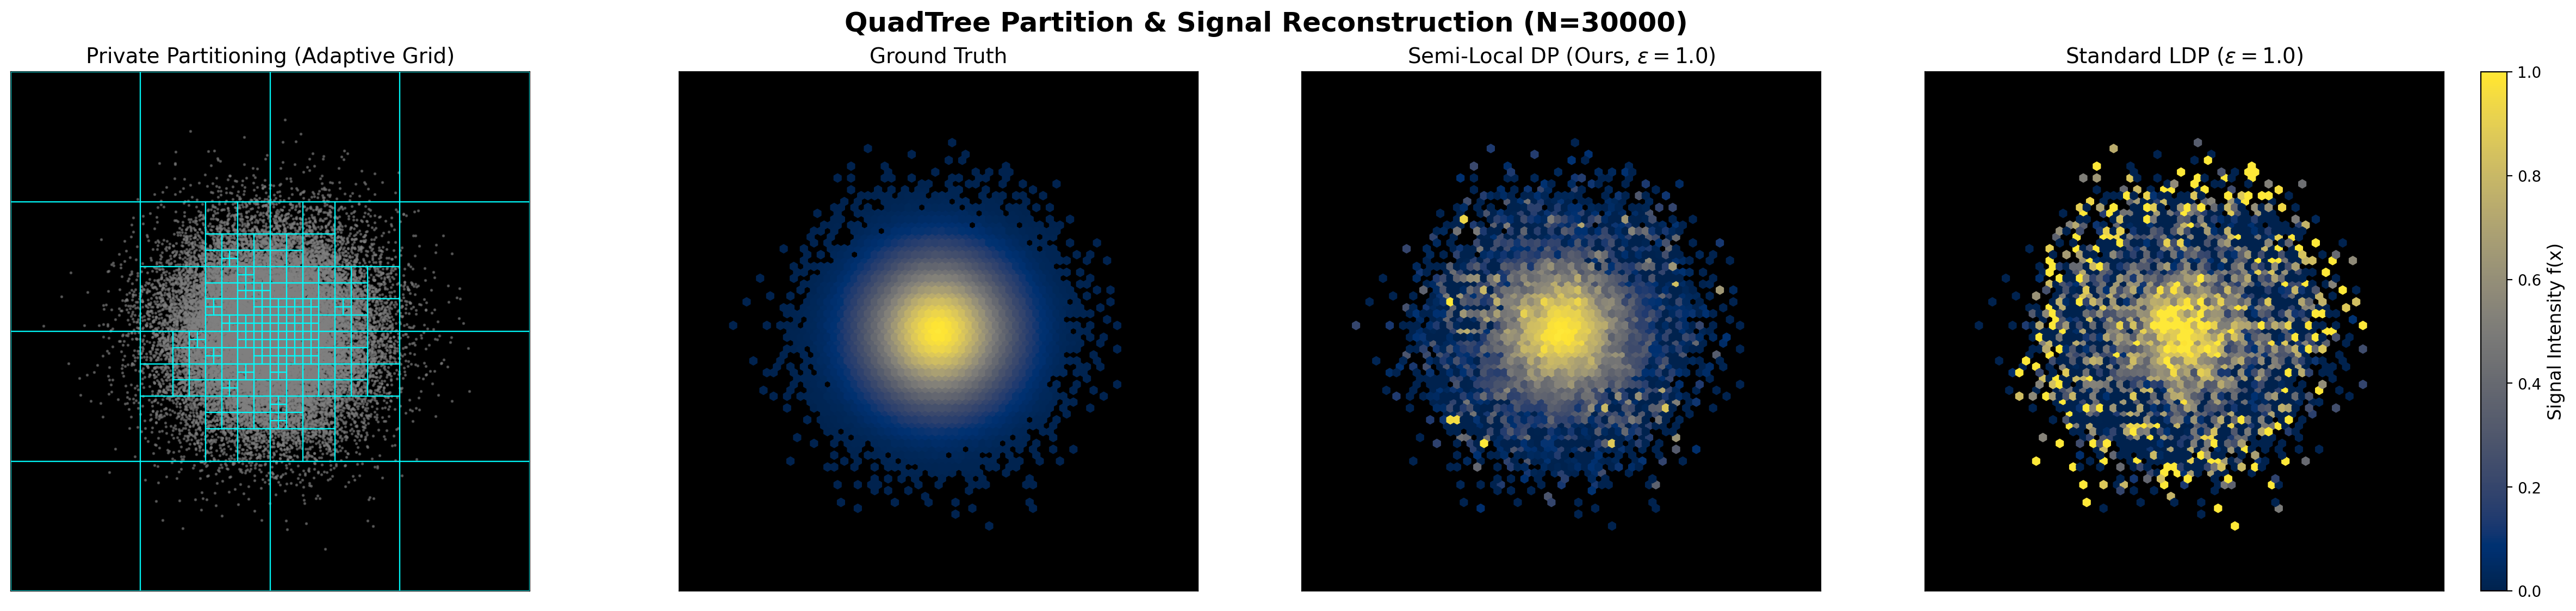

In [9]:

# ==========================================
# 2. PLOTTING (4 PANELS)
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5), constrained_layout=True)

# Display settings
xlims = [-10, 10] # Zoom in slightly towards the center
ylims = [-10, 10]
vmin, vmax = 0.0, 1.0 
cmap_heat = sns.color_palette("cividis", as_cmap=True)

# --- PLOT 1: TREE DEPTH MAP (New!) ---
ax_reg = axes[0]
ax_reg.set_title(f'Private Partitioning (Adaptive Grid)', fontsize=14)
ax_reg.set_facecolor('black') # Dark background

# 1.1. Plot raw points (gray/white)
ax_reg.scatter(pts[:, 0], pts[:, 1], s=1, c='gray', alpha=0.5, label='Raw Data')

# 1.2. Overlay region rectangles (Cyan)
for cell in leaves:
    width = cell.x_max - cell.x_min
    height = cell.y_max - cell.y_min
    
    rect = patches.Rectangle(
        (cell.x_min, cell.y_min), width, height,
        linewidth=0.8, 
        edgecolor='cyan',    # Cyan border color
        facecolor='none',    # Transparent interior
        alpha=0.8,
        zorder=10
    )
    ax_reg.add_patch(rect)

ax_reg.set_xticks([])
ax_reg.set_yticks([])
ax_reg.set_xlim(xlims)
ax_reg.set_ylim(ylims)
ax_reg.set_aspect('equal')


# --- PLOTS 2, 3, 4: SIGNALS (Heatmaps) ---
data_list = [
    (f_vals,    'Ground Truth'),
    (vals_sldp, f'Semi-Local DP (Ours, $\epsilon={eps_plot}$)'),
    (vals_ldp,  f'Standard LDP ($\epsilon={eps_plot}$)')
]

for ax, (values, title) in zip(axes[1:], data_list):
    hb = ax.hexbin(
        pts[:, 0], pts[:, 1], 
        C=values, 
        gridsize=70, 
        cmap=cmap_heat,
        extent=[xlims[0], xlims[1], ylims[0], ylims[1]],
        vmin=vmin, vmax=vmax,
        reduce_C_function=np.mean
    )
    ax.set_title(title, fontsize=14)
    ax.set_facecolor('black') # Background for empty space
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# Common Colorbar for signals
# Attach it to the last plot, but it is relevant for all three on the right
cbar_sig = fig.colorbar(hb, ax=axes[1:], orientation='vertical', fraction=0.02, pad=0.02)
cbar_sig.set_label('Signal Intensity f(x)', fontsize=12)

plt.suptitle(f'QuadTree Partition & Signal Reconstruction (N={N_plot})', fontsize=18, weight='bold')
plt.show()